In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


EXPERIMENTS = [
    "sn_kjOrdinalDM_xnjNormal",
    "sn_kjOrdinalDM_xnjNonNormal",
    "sn_kjOrdinalUniform_xnjNormal",
    "sn_kjOrdinalUniform_xnjNonNormal",
    "sn_kjContinuousUniform",
    "sn_kjContinuousBeta",
    "xiNearNormal_kjContinuousUniform",
    "xiNearNormal_kjContinuousBeta",
    "xiNearNormalWithNoise_kjContinuousBeta",
]

titles = [
        "Exp 1: S + Ordinal kj (DM) + X (Normal)",
        "Exp 2: S + Ordinal kj (DM) + X (Non-Normal)",
        "Exp 3: S + Ordinal kj (Uniform) + X (Normal)",
        "Exp 4: S + Ordinal kj (Uniform) + X (Non-Normal)",
        "Exp 5: S + Continuous kj (Uniform)",
        "Exp 6: S + Continuous kj (Skewed)",
        "Exp 7: xi (Normal) + Continuous kj (Uniform)",
        "Exp 8: xi (Normal) + Continuous kj (Skewed)",
        "Exp 9: xi (Normal + Noise) + Continuous kj (Skewed)"
    ]
code2title = dict(zip(EXPERIMENTS, titles))
title2code = {v: k for k, v in code2title.items()}  # optional, reverse map

In [42]:
df_old = pd.read_csv("../all_results_12bio.csv")
df_tr  = pd.read_csv("../all_results_12bio_transformer.csv")
df_tr["kendalls_tau"] = (1 - df_tr["kendalls_tau"]) / 2

# transformer csv uses short codes -> map to titles used in df_old
df_tr["E"] = df_tr["E"].map(code2title).fillna(df_tr["E"])

# ensure runtime exists (optional)
if "runtime" not in df_tr.columns:
    df_tr["runtime"] = np.nan

df_all = pd.concat([df_old, df_tr], ignore_index=True)

# make sure nothing weird is missing
df = df_all.dropna(subset=["E", "algo"])

df.to_csv('12bio.csv', index=False)

In [43]:
def mean_ci(x):
    mean = x.mean()
    sem = x.std(ddof=1) / np.sqrt(len(x))
    ci = 1.96 * sem
    return mean, ci

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap

def plot_metric_by_E_pub(df, metric, ylabel, value_fmt="{:.3f}", title_wrap=38):
    """
    Publication-ready faceted bar plots with:
    - Consistent algo ordering (ranked globally)
    - Legend entries: "Algo (mean ± 95% CI)"
    - Annotations that don't overlap titles
    - Wrapped subplot titles
    Assumes mean_ci(vals) returns (mean, ci_half_width) for 95% CI.
    """

    def to_plot_space(m, ci, metric_name):
        """Transform mean and CI into the plotted space."""
        if metric_name == "kendalls_tau":
            # plot value = 1 - 2*tau
            return (1 - 2*m), (2*ci)  # CI scales by 2 under linear transform
        return m, ci

    # ---- global ranking across ALL E ----
    algos = sorted(df["algo"].dropna().unique().tolist())
    algo_stats = []
    for algo in algos:
        vals = df.loc[df["algo"] == algo, metric].dropna()
        if len(vals) == 0:
            continue
        m, ci = mean_ci(vals)
        m_plot, ci_plot = to_plot_space(m, ci, metric)
        algo_stats.append((algo, m_plot, ci_plot))

    # sort algos by global performance
    if metric == "kendalls_tau":
        # descending (higher better after transform)
        algo_stats.sort(key=lambda t: t[1], reverse=True)
    else:
        # ascending for MAE (lower better)
        algo_stats.sort(key=lambda t: t[1])

    ranked_algos = [a for a, _, _ in algo_stats]
    algo2legend = {
        a: f"{a} ({value_fmt.format(m)} ± {value_fmt.format(ci)})"
        for a, m, ci in algo_stats
    }

    Es = sorted(df["E"].dropna().unique().tolist())

    # ---- figure layout ----
    ncols = 3
    nrows = int(np.ceil(len(Es) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5.4 * ncols, 4.2 * nrows),
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    # color mapping (consistent + ranked)
    cmap = plt.cm.tab10.colors
    colors = [cmap[i % len(cmap)] for i in range(len(ranked_algos))]
    algo2color = dict(zip(ranked_algos, colors))

    for i, E in enumerate(Es):
        ax = axes[i]
        df_E = df[df["E"] == E]

        means, cis = [], []
        for algo in ranked_algos:
            vals = df_E.loc[df_E["algo"] == algo, metric].dropna()
            if len(vals) == 0:
                means.append(np.nan)
                cis.append(0.0)
                continue

            m, ci = mean_ci(vals)
            m_plot, ci_plot = to_plot_space(m, ci, metric)

            means.append(m_plot)
            cis.append(ci_plot)

        x = np.arange(len(ranked_algos))

        bars = ax.bar(
            x,
            means,
            yerr=cis,
            capsize=3.5,
            color=[algo2color[a] for a in ranked_algos],
            edgecolor="black",
            linewidth=0.6,
            alpha=0.92
        )

        # ---- make room above bars + annotate without overlap ----
        finite_heights = np.array([m for m in means if np.isfinite(m)])
        finite_errs = np.array([c for m, c in zip(means, cis) if np.isfinite(m)])

        if len(finite_heights) > 0:
            top = float(np.max(finite_heights + finite_errs))
            bottom = float(np.min(finite_heights - finite_errs))
            pad = 0.18 * (top - bottom + 1e-9)  # adaptive padding
            ax.set_ylim(bottom - 0.05 * abs(bottom), top + pad)

        for bar, m in zip(bars, means):
            if not np.isfinite(m):
                continue
            ax.annotate(
                value_fmt.format(m),
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4),                 # 4 points above bar top
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                clip_on=False
            )

        # ---- titles & ticks (wrapped, clean) ----
        ax.set_title(textwrap.fill(str(E), width=title_wrap), fontsize=11, pad=10)

        ax.set_xticks(x)
        ax.set_xticklabels(ranked_algos, rotation=30, ha="right", fontsize=9)

        if i % ncols == 0:
            ax.set_ylabel(ylabel, fontsize=11)

        ax.grid(axis="y", linestyle="--", alpha=0.25, linewidth=0.8)
        ax.set_axisbelow(True)

        # thin spines for publication
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)

    # remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # ---- global legend: ranked order + mean±CI ----
    handles = [
        plt.Rectangle((0, 0), 1, 1,
                      facecolor=algo2color[a],
                      edgecolor="black",
                      linewidth=0.6)
        for a in ranked_algos
    ]
    labels = [algo2legend[a] for a in ranked_algos]

    # give extra bottom margin for legend + rotated x labels
    fig.subplots_adjust(bottom=0.20, hspace=0.55, wspace=0.25)

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,                 # use 2 columns to avoid overly wide legend
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.5, 0.02)
    )

    return fig


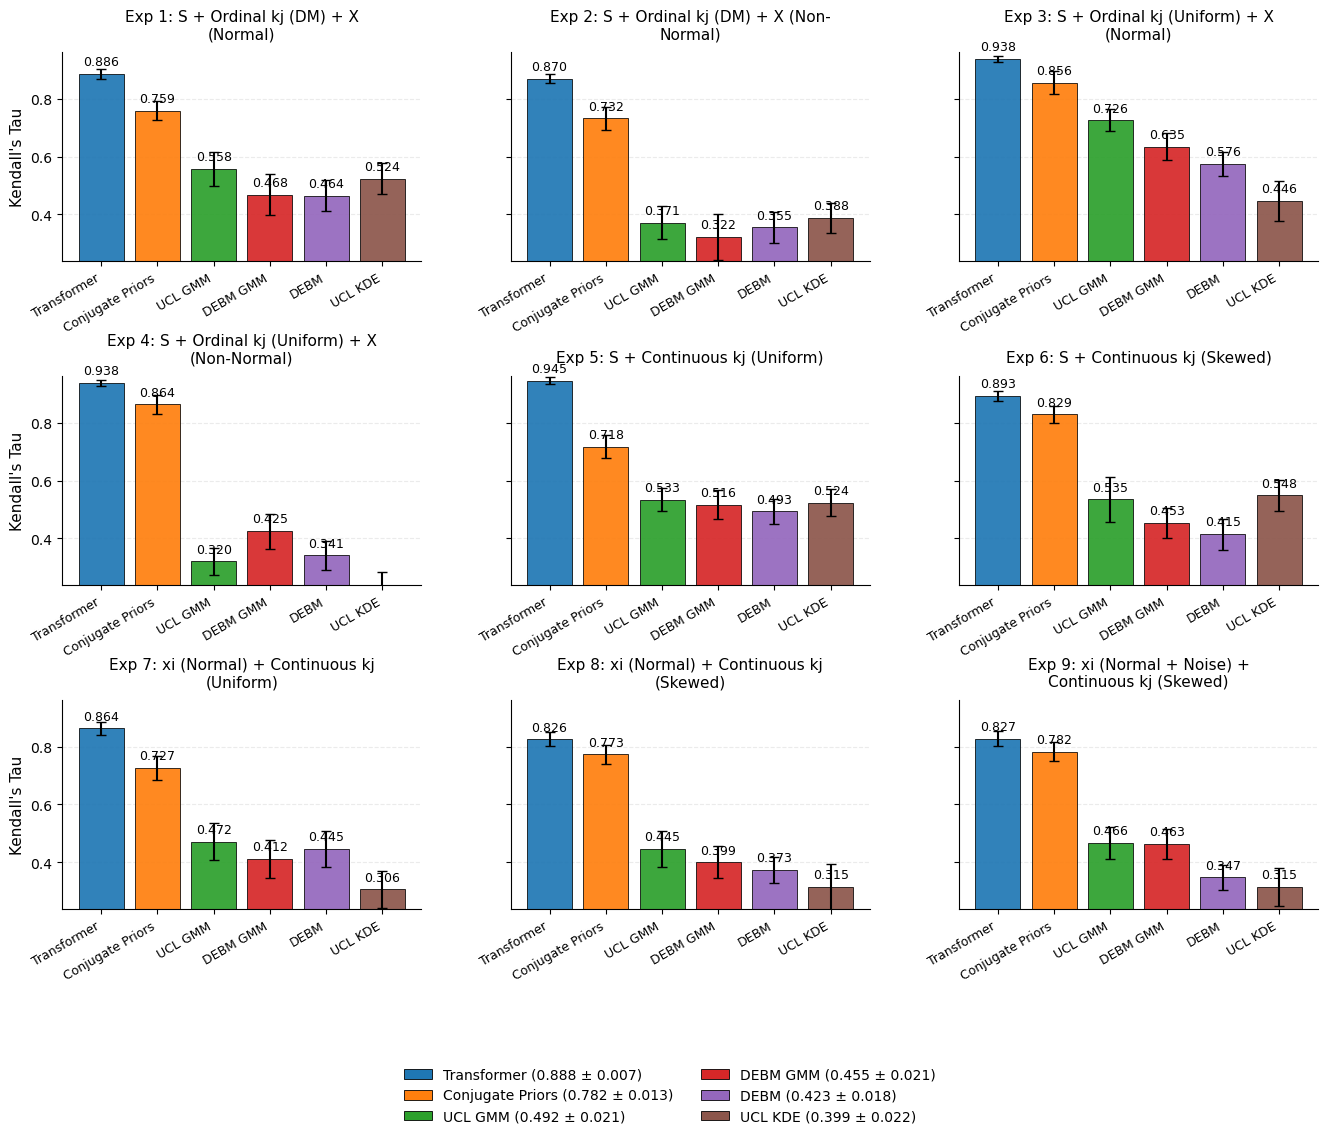

In [45]:
fig_tau = plot_metric_by_E_pub(
    df,
    metric="kendalls_tau",
    ylabel="Kendall's Tau",
    value_fmt="{:.3f}"
)


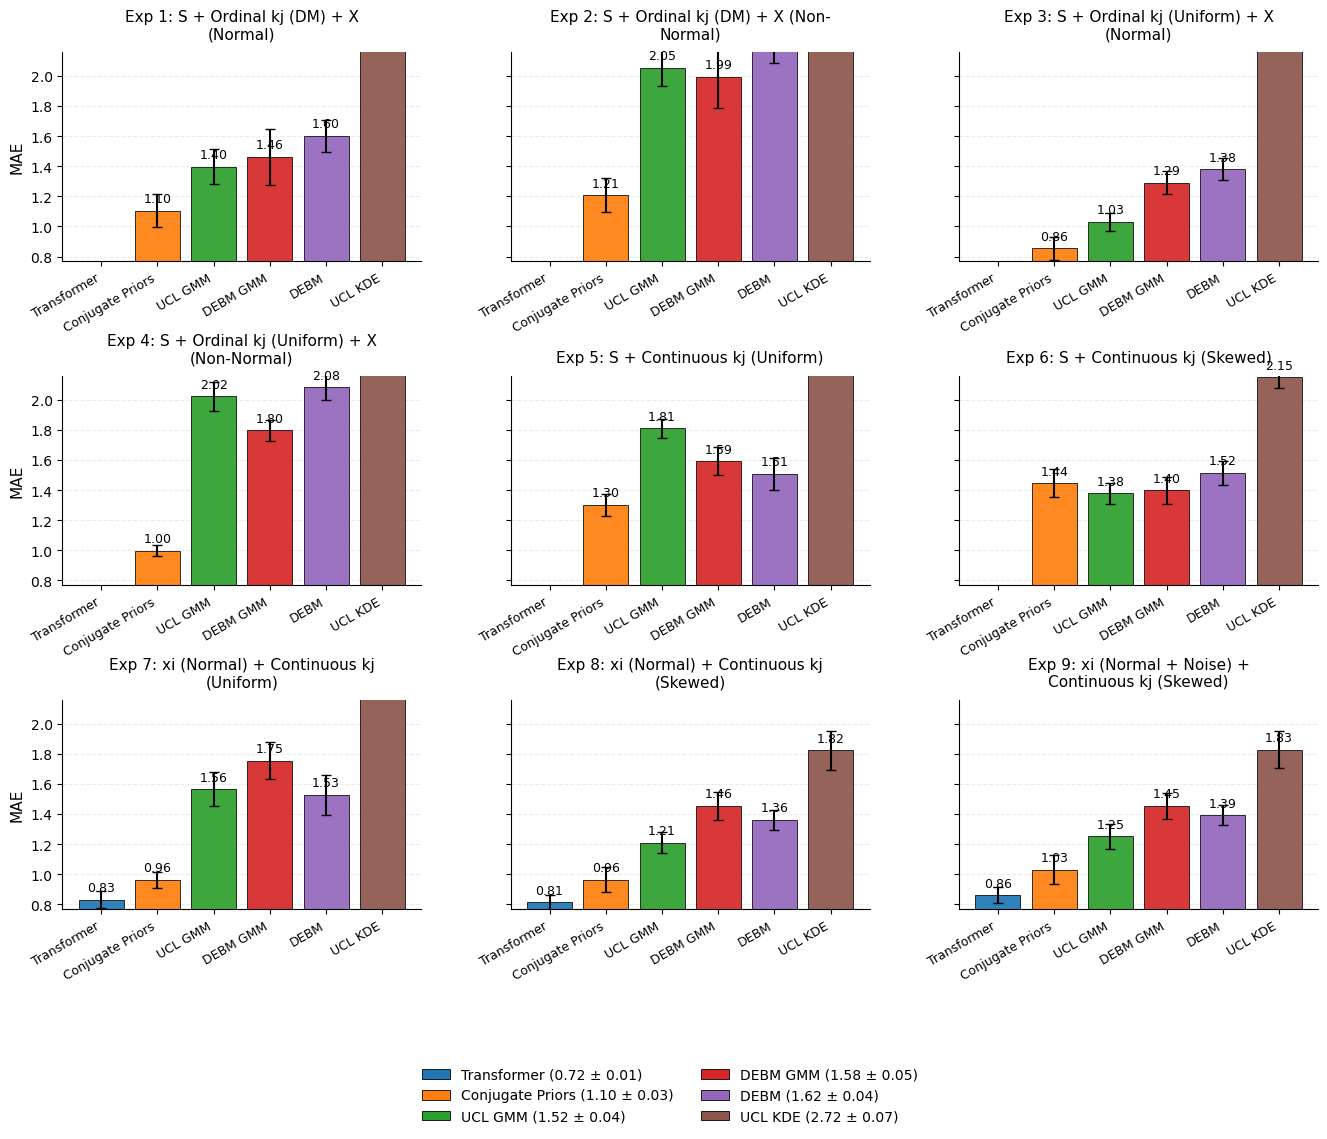

In [46]:
fig_mae = plot_metric_by_E_pub(
    df,
    metric="mae",
    ylabel="MAE",
    value_fmt="{:.2f}"
)
